<a href="https://colab.research.google.com/github/tataviviejoeney641-crypto/projeto-financas/blob/main/Risco_saude_EZ_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Machine Learning na Saúde: Projeto Completo do Zero**

In [1]:
# Importando Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('fivethirtyeight')
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset (1).csv')

In [5]:
# Observando
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [6]:
df.tail()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
4995,42,75,187,medium,7.2,low,no,no,yes,driver,21.4,low
4996,39,86,183,low,7.4,low,no,no,yes,engineer,25.7,high
4997,48,56,194,none,7.2,high,yes,yes,yes,engineer,14.9,high
4998,34,109,148,medium,9.9,medium,no,no,yes,doctor,49.8,low
4999,72,47,149,high,6.3,medium,no,no,yes,driver,21.2,low


In [7]:
# Observando linhas e colunas
df.shape

(5000, 12)

In [8]:
# Informações sobre os tipos de variáveis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [9]:
# Dados estatísticos
df.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [10]:
# Observando a existencia de valores nulos
df.isnull().sum()

,0
age,0
weight,0
height,0
exercise,0
sleep,0
sugar_intake,0
smoking,0
alcohol,0
married,0
profession,0


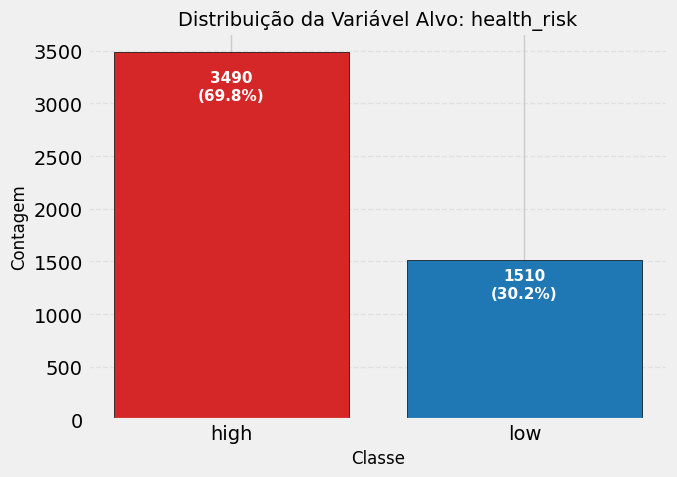

In [11]:
# Distribuição da variável alvo
# Contagem e porcentagem
counts = df['health_risk'].value_counts()
percent = (counts / counts.sum()) * 100

# Cores personalizadas
colors = {
    'low': '#1f77b4',   # azul
    'high': '#d62728'   # vermelho
}

plt.figure(figsize=(7,5))

# Gráfico de barras com cores individuais
bars = plt.bar(counts.index, counts.values,
               color=[colors[x] for x in counts.index],
               edgecolor='black')

# Títulos
plt.title("Distribuição da Variável Alvo: health_risk", fontsize=14)
plt.xlabel("Classe", fontsize=12)
plt.ylabel("Contagem", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Anotações: contagem + porcentagem abaixo de cada barra
for i, bar in enumerate(bars):
    cls = counts.index[i]
    value = counts.values[i]
    pct = percent.values[i]

    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - (bar.get_height()*0.05),
             f"{value}\n({pct:.1f}%)",
             ha='center', va='top', color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

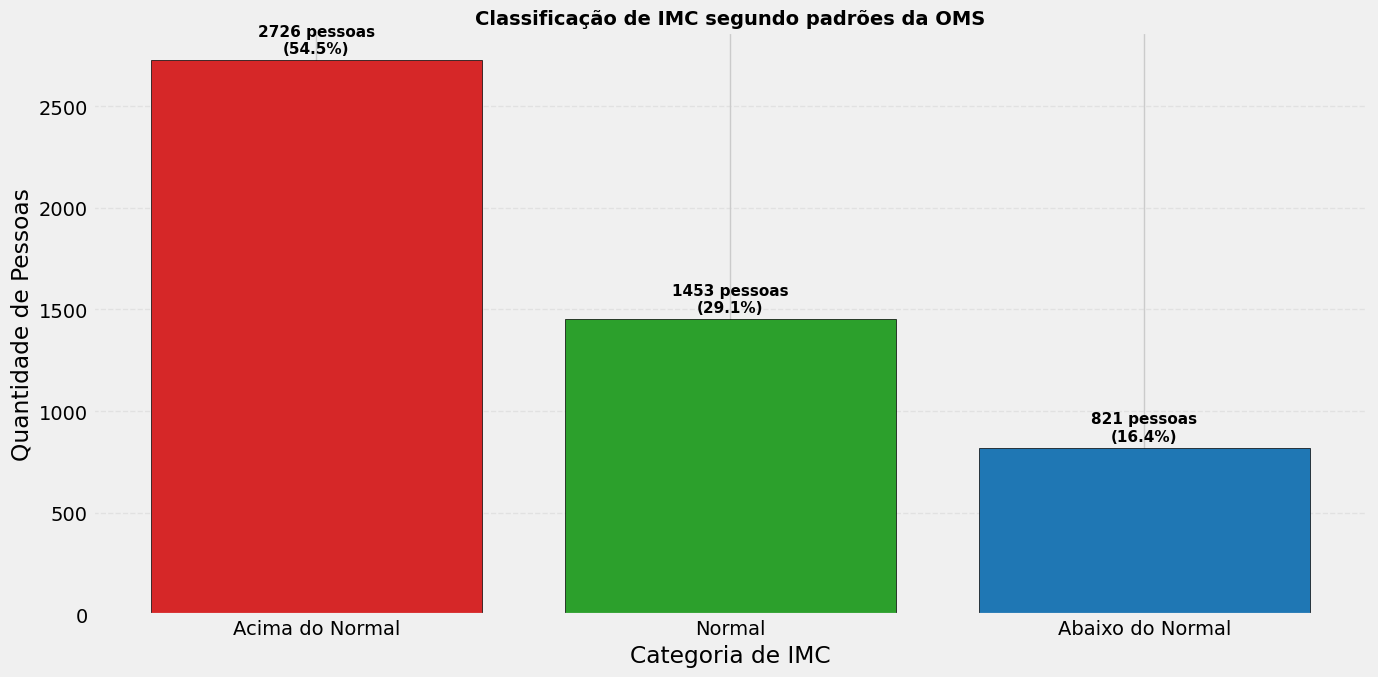

In [12]:
# Classificação conforme OMS

# Criando dataframe temporário
df_temp = df.copy()

# Cria categoria de IMC (somente no df_temp)
df_temp['bmi_category'] = df_temp['bmi'].apply(
    lambda x: 'Abaixo do Normal' if x < 18.5 else
              'Normal' if 18.5 <= x <= 24.9 else
              'Acima do Normal'
)

# Contagem
counts = df_temp['bmi_category'].value_counts()

# Cores personalizadas
colors = {
    'Abaixo do Normal': '#1f77b4',   # azul
    'Normal': '#2ca02c',            # verde
    'Acima do Normal': '#d62728'    # vermelho
}

plt.figure(figsize=(14,7))

bars = plt.bar(
    counts.index,
    counts.values,
    color=[colors[c] for c in counts.index],
    edgecolor='black'
)

# Título + eixos
plt.title("Classificação de IMC segundo padrões da OMS", fontsize=14, fontweight='bold')
plt.xlabel("Categoria de IMC")
plt.ylabel("Quantidade de Pessoas")
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Anotações
total = counts.sum()
for i, bar in enumerate(bars):
    value = counts.values[i]
    pct = (value / total) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f"{value} pessoas\n({pct:.1f}%)",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

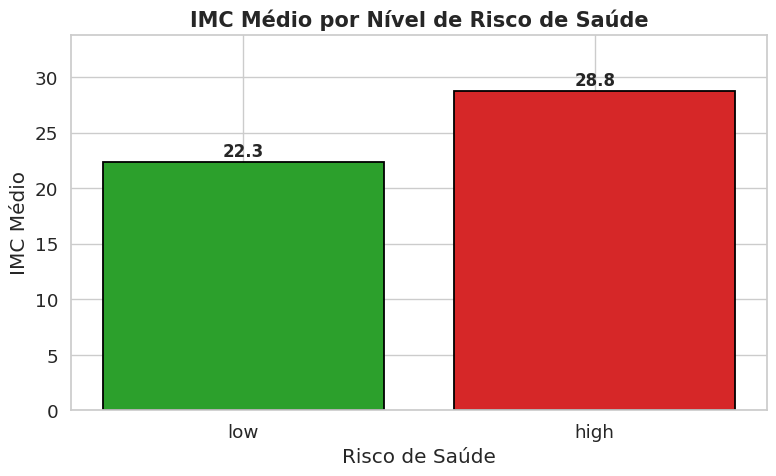

In [13]:
# Risco por IMC
sns.set(style="whitegrid", font_scale=1.2)

# Calcular IMC médio por classe de risco
bmi_mean = df.groupby('health_risk')['bmi'].mean().reset_index()

# Ordenar classes do mais saudável para o mais arriscado
order = ['low', 'high']
bmi_mean = bmi_mean.set_index('health_risk').loc[order].reset_index()

# Cores personalizadas
colors = {
    'low': '#2ca02c',     # verde = saudável
    'high': '#d62728'     # vermelho = risco alto
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    bmi_mean['health_risk'],
    bmi_mean['bmi'],
    color=[colors[x] for x in bmi_mean['health_risk']],
    edgecolor="black",
    linewidth=1.3
)

# Adicionar valores em cima das barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# Configurações do gráfico
plt.title("IMC Médio por Nível de Risco de Saúde", fontsize=15, fontweight='bold')
plt.xlabel("Risco de Saúde")
plt.ylabel("IMC Médio")
plt.ylim(0, bmi_mean['bmi'].max() + 5)

plt.tight_layout()
plt.show()

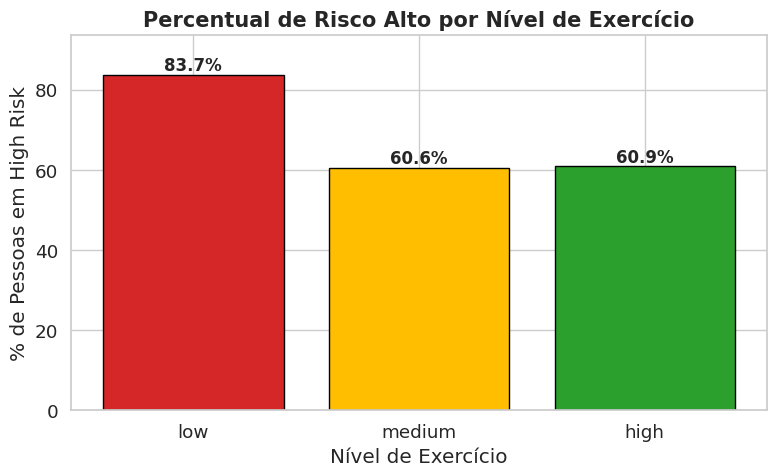

In [15]:
# Nível de exercícios
# Filtrar somente classes low e high
df_ex = df[df['health_risk'].isin(['low', 'high'])]

# Calcular porcentagem de HIGH dentro de cada nível de exercício
exercise_pct = (
    df_ex.groupby('exercise')['health_risk']
         .apply(lambda x: (x == 'high').mean() * 100)
         .reindex(['low', 'medium', 'high'])
)


sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8,5))
bars = plt.bar(
    exercise_pct.index,
    exercise_pct.values,
    color=['#d62728', '#ffbf00', '#2ca02c'],  # vermelho, amarelo, verde
    edgecolor="black"
)

# Adicionar valores nas barras
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha='center', fontsize=12, fontweight='bold'
    )

plt.title("Percentual de Risco Alto por Nível de Exercício", fontsize=15, fontweight='bold')
plt.xlabel("Nível de Exercício")
plt.ylabel("% de Pessoas em High Risk")
plt.ylim(0, exercise_pct.max() + 10)
plt.tight_layout()
plt.show()

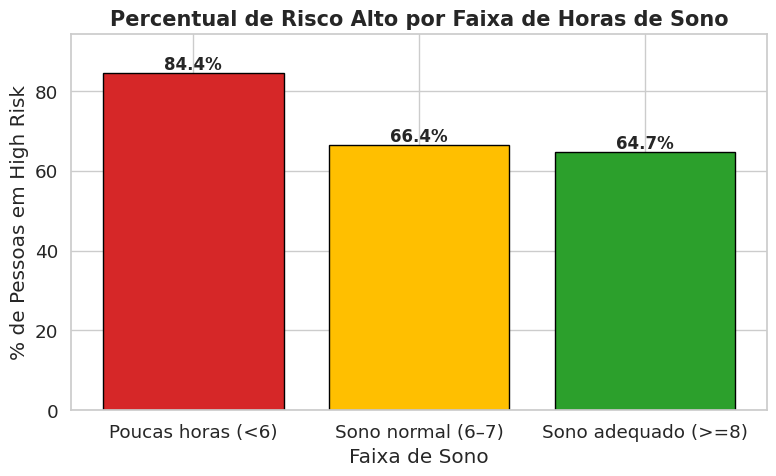

In [16]:
# Risco por horas de sono
# Filtrar apenas low e high
df_sleep = df[df['health_risk'].isin(['low', 'high'])]

# Criar faixas de sono (opcional para deixar mais didático)
df_sleep['sleep_cat'] = pd.cut(
    df_sleep['sleep'],
    bins=[0, 5.9, 6.9, 10],
    labels=['Poucas horas (<6)', 'Sono normal (6–7)', 'Sono adequado (>=8)']
)

# Calcular % de high risk por faixa
sleep_pct = (
    df_sleep.groupby('sleep_cat')['health_risk']
            .apply(lambda x: (x == 'high').mean() * 100)
)

# Visual
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8,5))

bars = plt.bar(
    sleep_pct.index,
    sleep_pct.values,
    color=['#d62728', '#ffbf00', '#2ca02c'],   # vermelho, amarelo, verde
    edgecolor='black'
)

# Adicionar % em cima das barras
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha='center', fontsize=12, fontweight='bold'
    )

plt.title("Percentual de Risco Alto por Faixa de Horas de Sono", fontsize=15, fontweight='bold')
plt.ylabel("% de Pessoas em High Risk")
plt.xlabel("Faixa de Sono")
plt.ylim(0, sleep_pct.max() + 10)
plt.tight_layout()
plt.show()

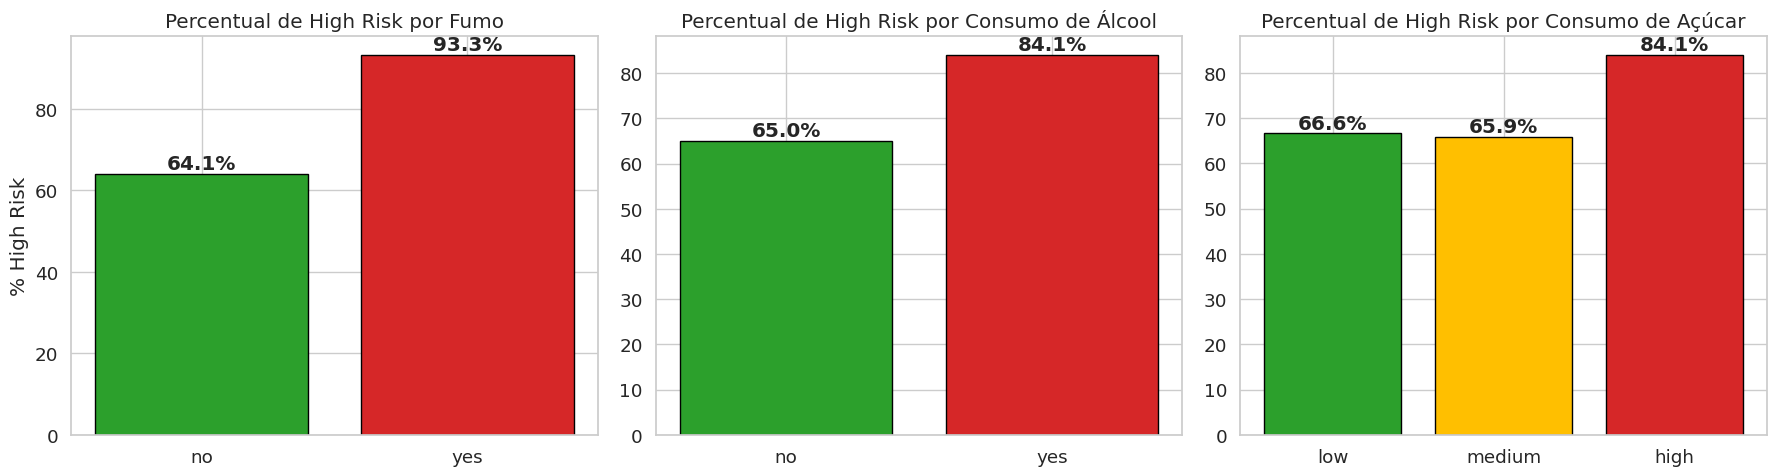

In [17]:
# Risco por hábito
sns.set(style="whitegrid", font_scale=1.2)

# Apenas classes low/high
df_hab = df[df['health_risk'].isin(['low', 'high'])]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# FUMANTE
smoke_pct = (
    df_hab.groupby('smoking')['health_risk']
          .apply(lambda x: (x=='high').mean()*100)
)

axes[0].bar(smoke_pct.index, smoke_pct.values,
            color=['#2ca02c', '#d62728'], edgecolor='black')

for i, v in enumerate(smoke_pct.values):
    axes[0].text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')

axes[0].set_title("Percentual de High Risk por Fumo")
axes[0].set_ylabel("% High Risk")


# ÁLCOOL
alc_pct = (
    df_hab.groupby('alcohol')['health_risk']
          .apply(lambda x: (x=='high').mean()*100)
)

axes[1].bar(alc_pct.index, alc_pct.values,
            color=['#2ca02c', '#d62728'], edgecolor='black')

for i, v in enumerate(alc_pct.values):
    axes[1].text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')

axes[1].set_title("Percentual de High Risk por Consumo de Álcool")


# AÇÚCAR
sugar_pct = (
    df_hab.groupby('sugar_intake')['health_risk']
          .apply(lambda x: (x=='high').mean()*100)
          .loc[['low','medium','high']]  # ordem coerente
)

axes[2].bar(sugar_pct.index, sugar_pct.values,
            color=['#2ca02c', '#ffbf00', '#d62728'], edgecolor='black')

for i, v in enumerate(sugar_pct.values):
    axes[2].text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')

axes[2].set_title("Percentual de High Risk por Consumo de Açúcar")
plt.tight_layout()
plt.show()

In [18]:
# Definição dos maus hábitos
cond = (
    (df['smoking'] == 'yes') &
    (df['alcohol'] == 'yes')
)

# Filtra essas pessoas
df_bad = df[cond]

# Calcula % de high risk
prob_high = (df_bad['health_risk'] == 'high').mean() * 100

len_total = len(df_bad)

prob_high, len_total

(np.float64(100.0), 249)

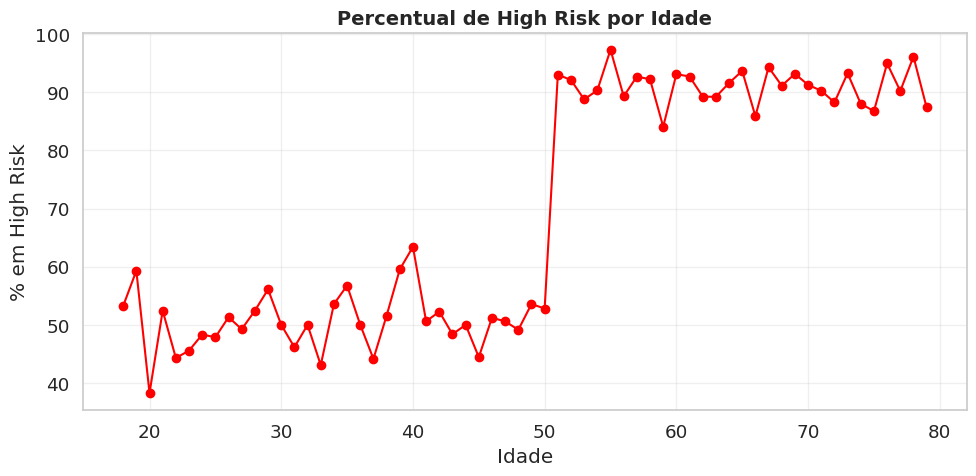

In [19]:
# Observando o risco por idade
# Filtrar apenas low e high
df_age = df[df['health_risk'].isin(['low', 'high'])]

# Calcular % high risk por idade
age_pct = (
    df_age.groupby('age')['health_risk']
          .apply(lambda x: (x == 'high').mean() * 100)
)

plt.figure(figsize=(10,5))
plt.plot(age_pct.index, age_pct.values, marker='o', color='red')
plt.title("Percentual de High Risk por Idade", fontsize=14, fontweight="bold")
plt.xlabel("Idade")
plt.ylabel("% em High Risk")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

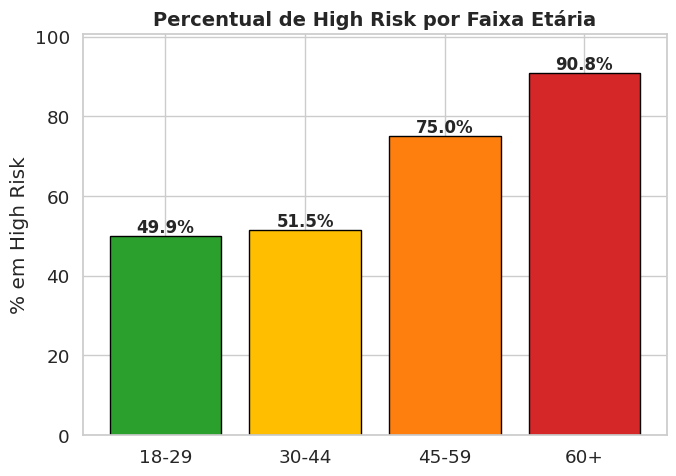

In [20]:
# Criando dataframe temporário
df_temp = df.copy()

# Criando faixas de idade (apenas no df_temp)
df_temp['age_group'] = pd.cut(
    df_temp['age'],
    bins=[17, 29, 44, 59, 90],
    labels=['18-29', '30-44', '45-59', '60+']
)

# % high risk por faixa
age_group_pct = (
    df_temp[df_temp['health_risk'].isin(['low','high'])]
      .groupby('age_group')['health_risk']
      .apply(lambda x: (x=='high').mean()*100)
)

plt.figure(figsize=(7,5))
bars = plt.bar(
    age_group_pct.index,
    age_group_pct.values,
    color=['#2ca02c','#ffbf00','#ff7f0e','#d62728'],
    edgecolor='black'
)

# Texto nas barras
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.1f}%",
        ha='center', fontsize=12, fontweight='bold'
    )

plt.title("Percentual de High Risk por Faixa Etária", fontsize=14, fontweight="bold")
plt.ylabel("% em High Risk")
plt.ylim(0, max(age_group_pct.values)+10)
plt.tight_layout()
plt.show()

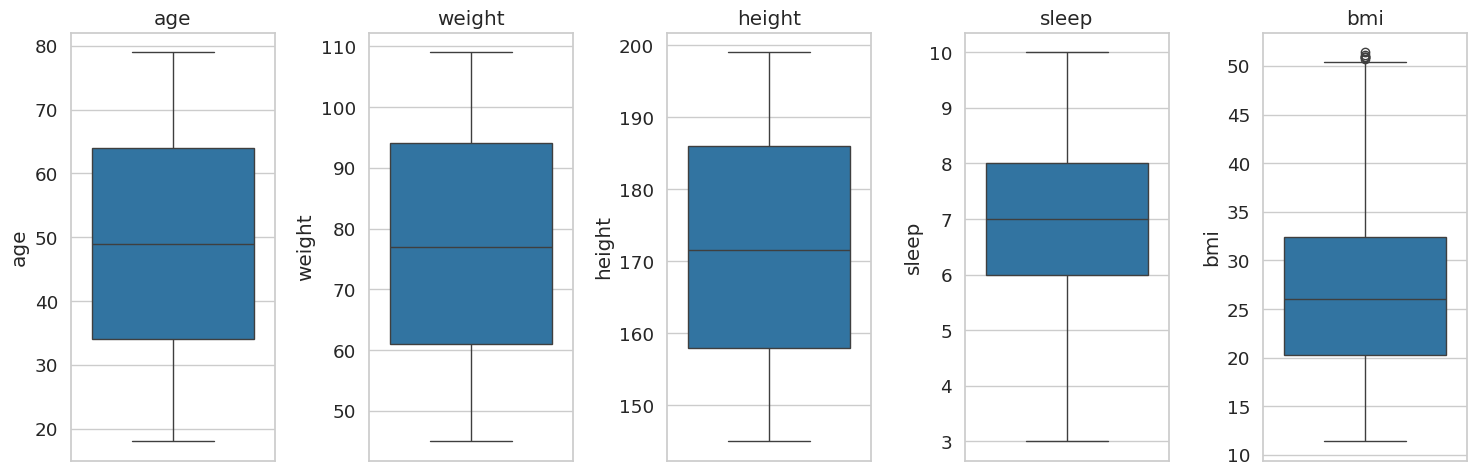

,Outliers
age,0
weight,0
height,0
sleep,0
bmi,6


In [21]:
# Observando outliers
sns.set(style="whitegrid", font_scale=1.2)

# Selecionando colunas numéricas automaticamente
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plotando os boxplots
plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(y=df[col], color="#1f77b4")
    plt.title(col)

plt.tight_layout()
plt.show()

# Calculando os outliers (IQR)
outliers = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

# Tabela
pd.DataFrame.from_dict(outliers, orient='index', columns=['Outliers'])

In [22]:
# Selecionando apenas os outliers de BMI
bmi_outliers = df[(df['bmi'] < lower) | (df['bmi'] > upper)]

bmi_outliers

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
544,40,107,145,high,7.3,high,no,no,no,office_worker,50.9,high
2814,64,107,145,low,8.2,medium,no,no,no,engineer,50.9,high
3153,30,109,146,medium,6.5,medium,no,no,yes,student,51.1,low
3964,78,107,145,medium,7.6,medium,no,yes,yes,doctor,50.9,high
4708,40,108,145,low,7.5,high,no,no,yes,doctor,51.4,high
4912,18,108,146,none,8.6,medium,no,no,yes,engineer,50.7,high


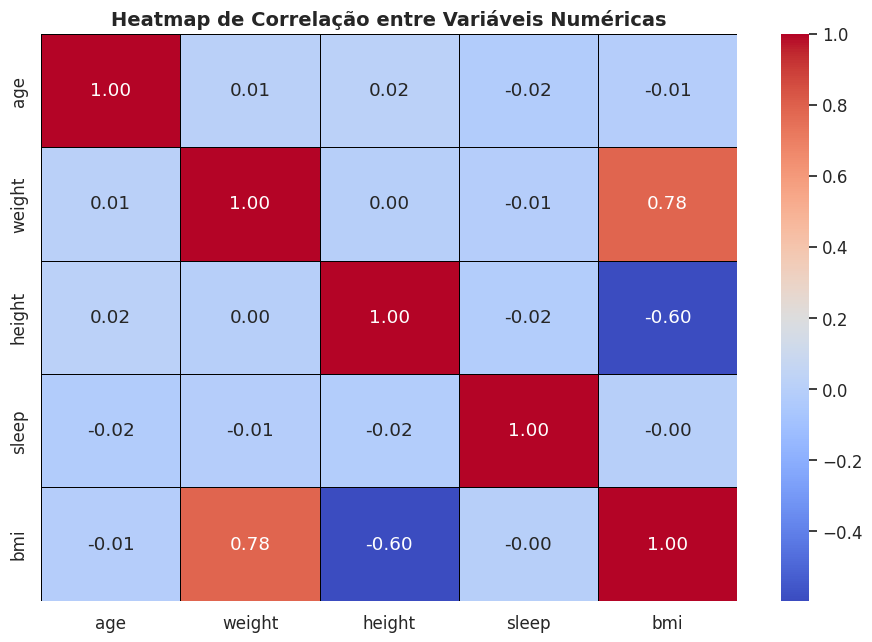

In [23]:
# Observando correlações entre variáveis numéricas
sns.set(style="whitegrid", font_scale=1.1)

# Seleciona apenas variáveis numéricas
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlação
corr = num_cols.corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='black',
    fmt=".2f"
)

plt.title("Heatmap de Correlação entre Variáveis Numéricas", fontsize=14, fontweight='bold')
plt.show()

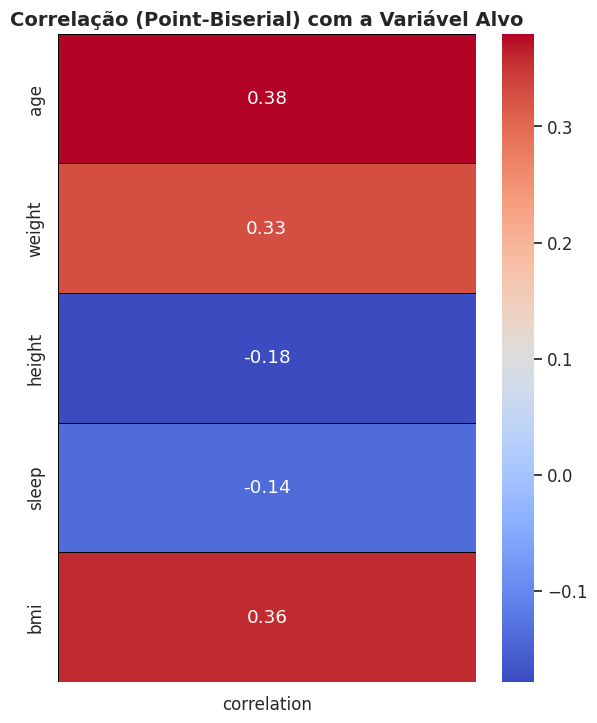

In [24]:
from scipy.stats import pointbiserialr

# Cria variável binária
df_temp = df.copy()
df_temp['risk_binary'] = df_temp['health_risk'].map({'low':0, 'high':1})

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_pb = {}

for col in num_cols:
    if col != 'risk_binary':
        corr, p = pointbiserialr(df_temp['risk_binary'], df_temp[col])
        corr_pb[col] = corr

# DataFrame para heatmap
corr_df = pd.DataFrame.from_dict(corr_pb, orient='index', columns=['correlation'])

plt.figure(figsize=(6,8))
sns.heatmap(
    corr_df,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='black',
    fmt=".2f"
)

plt.title("Correlação (Point-Biserial) com a Variável Alvo", fontsize=14, fontweight='bold')
plt.show()

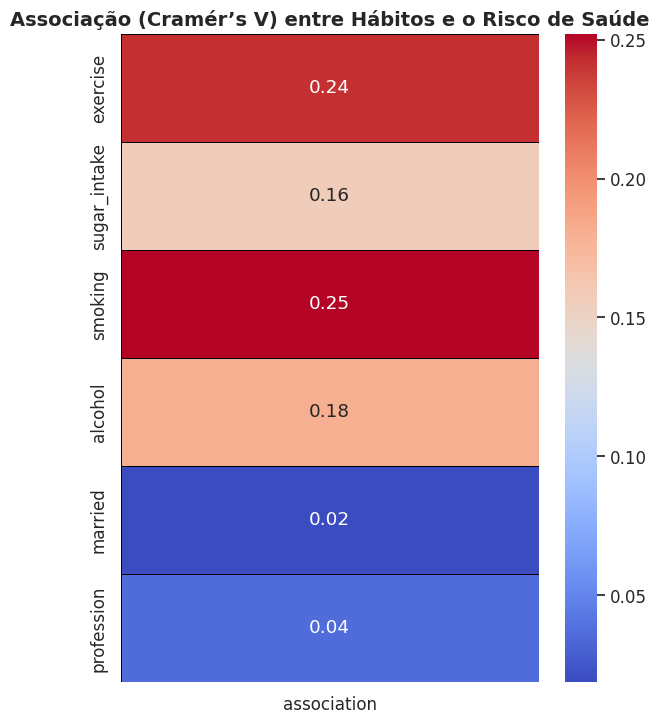

In [25]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

cat_cols = ['exercise', 'sugar_intake', 'smoking', 'alcohol', 'married', 'profession']

results_cv = {}

for col in cat_cols:
    results_cv[col] = cramers_v(df[col], df['health_risk'])

# Transformar em DataFrame
cv_df = pd.DataFrame.from_dict(results_cv, orient='index', columns=['association'])

plt.figure(figsize=(6,8))
sns.heatmap(
    cv_df,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='black',
    fmt=".2f"
)

plt.title("Associação (Cramér’s V) entre Hábitos e o Risco de Saúde", fontsize=14, fontweight='bold')
plt.show()

In [26]:
# Excluindo as variáveis irrelevantes para o modelo
df_model = df.drop(columns=['profession', 'married', 'bmi'])

In [27]:
# Convertendo a variável alvo para formato binário
df_model['health_risk'] = df_model['health_risk'].map({'low':0, 'high':1})

In [28]:
# Observando
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   health_risk   5000 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 351.7+ KB


In [29]:
# Separar features e target
X = df_model.drop(columns=['health_risk'])
y = df_model['health_risk']

In [30]:
# Separando 70% para treino
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Separando 15% para validação e 15% para teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Tamanhos finais:")
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)



Tamanhos finais:
Treino: (3500, 8)
Validação: (750, 8)
Teste: (750, 8)


In [31]:
# Definindo as colunas
cat_cols = ['exercise', 'sugar_intake', 'smoking', 'alcohol']
num_cols = ['age', 'weight', 'height', 'sleep']

In [32]:
# Convertendo colunas categóricas para numéricas
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
# Aplicando apenas nos dados de treino
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_val_cat   = encoder.transform(X_val[cat_cols])
X_test_cat  = encoder.transform(X_test[cat_cols])

In [33]:
# Concatenando com as numéricas
X_train_final = np.hstack([X_train[num_cols].values, X_train_cat])
X_val_final   = np.hstack([X_val[num_cols].values, X_val_cat])
X_test_final  = np.hstack([X_test[num_cols].values, X_test_cat])

In [34]:
from sklearn.tree import DecisionTreeClassifier

# Criando o modelo
tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

tree.fit(X_train_final, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [35]:
# Previsões na validação
y_val_pred = tree.predict(X_val_final)

print("VALIDAÇÃO")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))


# Previsões no teste
y_test_pred = tree.predict(X_test_final)

print("TESTE")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

VALIDAÇÃO
Accuracy: 0.96
Precision: 0.9678030303030303
Recall: 0.9751908396946565
F1-score: 0.9714828897338403

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       226
           1       0.97      0.98      0.97       524

    accuracy                           0.96       750
   macro avg       0.95      0.95      0.95       750
weighted avg       0.96      0.96      0.96       750

TESTE
Accuracy: 0.9546666666666667
Precision: 0.9621928166351607
Recall: 0.9732313575525813
F1-score: 0.967680608365019

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92       227
           1       0.96      0.97      0.97       523

    accuracy                           0.95       750
   macro avg       0.95      0.94      0.95       750
weighted avg       0.95      0.95      0.95       750



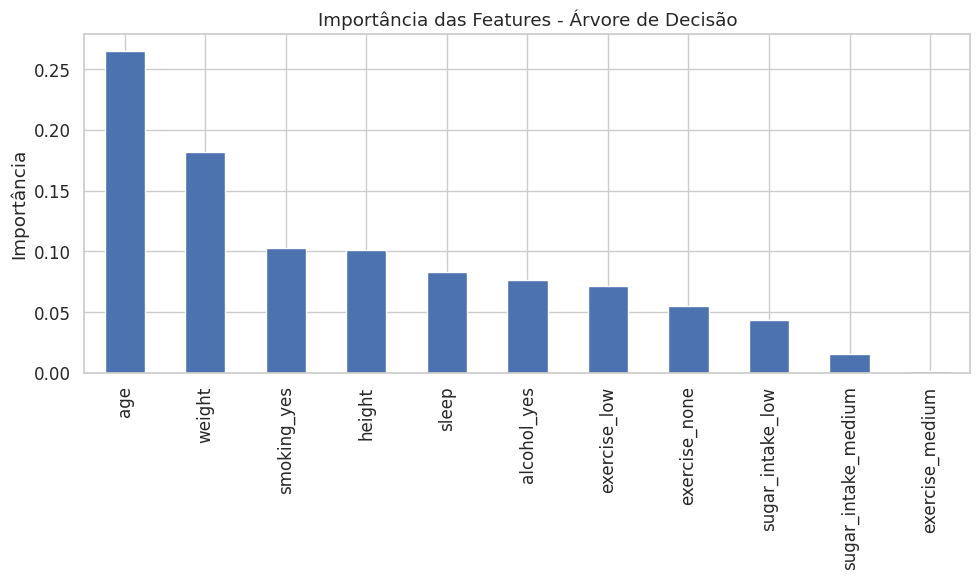

In [36]:
# Analisando a importância de cada variável
cat_feature_names = encoder.get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])
importance = pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title("Importância das Features - Árvore de Decisão")
plt.ylabel("Importância")
plt.tight_layout()
plt.show()

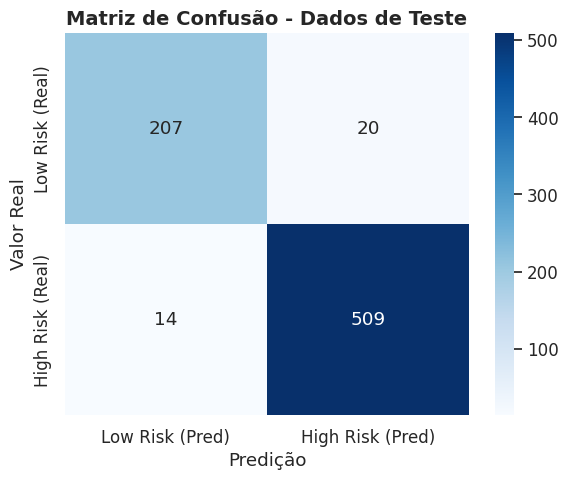

In [37]:
# Previsões do modelo no TESTE
y_test_pred = tree.predict(X_test_final)

# Matriz de confusão
cm = confusion_matrix(y_test, y_test_pred)

# Plot da matriz
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk (Pred)', 'High Risk (Pred)'],
            yticklabels=['Low Risk (Real)', 'High Risk (Real)'])
plt.title("Matriz de Confusão - Dados de Teste", fontsize=14, fontweight='bold')
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()